# Load packages

In [1]:
import scanpy as sc

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
from scipy.stats import fisher_exact

# Load data

In [11]:
data = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_RCNs.csv', index_col=0)

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_64844/1161626377.py:1: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_RCNs.csv', index_col=0)


In [14]:
data

,S9.6,HER3,panCK,SMA,CD45,Ki67_2,CD4,FOXP3,CD8a,CD11b,...,antioxidant_GLUT1,NQO1_GCLC_VIM,celltype_2,celltype_1,Tumor_state,GCLC_VIM,CellCategory,SC45px_neigh_kmeans_10,RCNs,RCNs_2
CellID,,,,,,,,,,,,,,,,,,,,,
1,0.587351,0.668424,0.197573,0.119095,0.357855,0.221494,0.351031,0.261670,0.120537,0.641891,...,failed_classify,---,Other,Other.Stroma,Other.Stroma,Other.Stroma,Stroma,4,RCN3,Other_RCNs
10,0.711467,0.738836,0.522747,0.185507,0.275963,0.214838,0.374685,0.350623,0.029450,0.608733,...,failed_classify,+--,Tumor_+--,Tumor,Tumor,Tumor.GCLC-VIM-,Tumor,2,RCN1,Other_RCNs
10,0.803970,0.824031,0.331924,0.204348,0.355699,0.234078,0.518679,0.390894,0.161177,0.666724,...,failed_classify,+--,CD68.Macrophages,CD68.Macrophages,CD68.Macrophages,CD68.Macrophages,Immune,4,RCN3,Other_RCNs
100,0.744246,0.762114,0.531392,0.185345,0.246533,0.227313,0.392369,0.348677,0.023832,0.619029,...,failed_classify,+--,Tumor_+--,Tumor,Tumor,Tumor.GCLC-VIM-,Tumor,2,RCN1,Other_RCNs
100,0.796639,0.796858,0.357244,0.192493,0.431782,0.228827,0.489430,0.380457,0.156145,0.674359,...,failed_classify,---,Immune,Other.Immune,Other.Immune,Other.Immune,Immune,4,RCN3,Other_RCNs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99998,0.832069,0.723583,0.638020,0.130660,0.135379,0.173406,0.316902,0.220026,0.366662,0.634752,...,failed_classify,---,Tumor_---,Tumor,Tumor,Tumor.GCLC-VIM-,Tumor,2,RCN1,Other_RCNs
99999,0.770561,0.929819,0.451729,0.390374,0.620998,0.488494,0.532568,0.522331,0.467017,0.871813,...,failed_classify,-++,FOXP3.CD4.Tregs,Treg,Treg,Treg,Immune,1,RCN2,Other_RCNs
99999,0.678946,0.721054,0.228812,0.598502,0.598347,0.229858,0.528080,0.499220,0.232839,0.704152,...,failed_classify,-++,CD4.T.cells,CD4.T.cells,CD4.T.cells,CD4.T.cells,Immune,1,RCN2,Other_RCNs


In [ ]:
# Create a new column RCNs_2 based on RCNs
data['RCNs_2'] = data['RCNs']
# Set all non-RCN4 values to 'Other_RCNs'
data.loc[data['RCNs_2'] != 'RCN4', 'RCNs_2'] = 'Other_RCNs'

In [20]:
# Count the number of cells in each group for verification
rcn_counts = data['RCNs_2'].value_counts()
print(f"Cell counts in each group:\n{rcn_counts}")

# Check proportion of immune cells in each group
immune_counts = data[data['CellCategory'] == 'Immune'].groupby('RCNs_2').size()
total_counts = data.groupby('RCNs_2').size()
immune_proportions = (immune_counts / total_counts) * 100

print("\nImmune cell proportions:")
print(immune_proportions)

Cell counts in each group:
RCNs_2
Other_RCNs    3434793
RCN4           246979
Name: count, dtype: int64

Immune cell proportions:
RCNs_2
Other_RCNs    31.367654
RCN4          18.631948
dtype: float64


# Data preparation

In [17]:
def prepare_enrichment_data(data, y_name, y_group='Immune', y_group_column='GCLC_VIM', x_group_column='RCNs'):
    """
    Prepare data for enrichment analysis and bubble plot visualization.
    
    Args:
        data: DataFrame containing the cell data
        y_name: Column containing the y category
        y_group: Category of cells to filter
        y_group_column: Column to use for grouping
        x_group_column: Column containing x group information
        
    Returns:
        tuple: (df_proportion, df_pivot_counts, x_group_totals)
            - df_proportion: DataFrame with proportions of each group in each x group
            - df_pivot_counts: DataFrame with raw counts of each group in each x group
            - x_group_totals: Series with total cells in each x group
    """
    # Filter data by cell category
    data_filtered = data[data[y_name] == y_group]
    
    # Select the columns we want to compare
    data_subset = data_filtered[[y_group_column, x_group_column]]
    df = pd.DataFrame(data_subset)
    
    # Get the counts
    df_count = df.groupby([y_group_column, x_group_column]).size().reset_index(name="Count")
    df_pivot = df_count.pivot(index=y_group_column, columns=x_group_column, values="Count").fillna(0)
    
    # Calculate the total count for each x group
    x_group_totals = df_pivot.sum(axis=0)
    
    # Calculate the proportions
    df_proportion = df_pivot.div(x_group_totals, axis=1) * 100  # Multiply by 100 to get percentages
    
    # Keep the original count data for reference
    df_pivot_counts = df_pivot.copy()
    
    return df_proportion, df_pivot_counts, x_group_totals


In [18]:
# Example usage
df_proportion, df_pivot_counts, rcn_totals = prepare_enrichment_data(data = data,
                                                                     y_name = 'CellCategory',
                                                                     y_group = 'Immune',
                                                                     y_group_column = 'GCLC_VIM',
                                                                     x_group_column = 'RCNs_2')

In [19]:
df_proportion

RCNs_2,Other_RCNs,RCN4
GCLC_VIM,,
CD206.Macrophages,13.177015,24.753895
CD4.T.cells,20.868765,20.477215
CD68.Macrophages,21.108506,18.206315
CD8.T.cells,17.923565,9.937632
Other.Immune,17.850798,14.605472
Treg,9.071350,12.019471


In [25]:
df_proportion_2 = df_proportion.copy()
df_proportion_2['Other_RCNs'] = df_proportion_2['Other_RCNs'] / 31.367654 * 100
df_proportion_2['RCN4'] = df_proportion_2['RCN4'] / 18.631948 * 100
df_proportion_2

RCNs_2,Other_RCNs,RCN4
GCLC_VIM,,
CD206.Macrophages,42.008289,132.857258
CD4.T.cells,66.529570,109.903779
CD68.Macrophages,67.293863,97.715575
CD8.T.cells,57.140279,53.336515
Other.Immune,56.908299,78.389398
Treg,28.919442,64.510008


# Function

In [26]:

def create_enrichment_bubble_plot(group_a, group_b, df_proportion, a, output_path=None):
    """
    Create a bubble plot showing cell type enrichment between two RCNs.
    
    Args:
        group_a, group_b: The two groups to compare (e.g., 'RCN3', 'RCN7')
        df_proportion: Pivot table containing cell type proportion for each RCN
        a: Scaling factor for bubble sizes
        output_path: Optional path to save the plot
        
    Returns:
        Figure: Bubble plot showing cell type or other things enrichment between two groups
    """
    # Calculate Log2 fold change
    df_plot = df_proportion.copy()
    df_plot["Log2(Fold Change)"] = np.log2(df_plot[group_a] / df_plot[group_b].replace(0, 1))
    
    # Calculate p-values using fisher test for RCN1 vs RCN3 comparison
    p_values = []

    for cell_type in df_plot.index:
        # calculate the original counts from df_pivot_counts
        count_a = df_pivot_counts.loc[cell_type, group_a]
        count_b = df_pivot_counts.loc[cell_type, group_b]
    
        # calculate the total cells in each RCN
        total_a = rcn_totals[group_a]
        total_b = rcn_totals[group_b]
    
        # create arrays of 1s (cell is of this type) and 0s (cell is not of this type)
        contingency_table = [[count_a, count_b], 
                         [total_a - count_a, total_b - count_b]]
    
        # perform Fisher test
        _, p_value = fisher_exact(contingency_table)
        p_values.append(p_value)

    # Add p-values to the dataframe
    df_plot["P_value"] = p_values
    df_plot["-Log10(P value)"] = -np.log10(df_plot["P_value"].replace(0, 1e-10))
    print(df_plot['-Log10(P value)'].max())
    print(df_plot['-Log10(P value)'].min())
    
    # Create plot
    fig, ax = plt.subplots(figsize=(17, 15))
    
    # Set bubble sizes proportional to -Log10(P value)
    bubble_size = df_plot["-Log10(P value)"] * a
    
    # Use a diverging colormap for Log2 fold change
    # Determine the maximum absolute fold change for symmetric color scaling
    max_fold_change = max(abs(df_plot["Log2(Fold Change)"].min()), abs(df_plot["Log2(Fold Change)"].max()))
    norm = plt.Normalize(-max_fold_change, max_fold_change)
    
    # Create scatter plot with color based on Log2 fold change
    scatter = ax.scatter(
        df_plot["Log2(Fold Change)"],
        df_plot.index,
        s=bubble_size,
        c=df_plot["Log2(Fold Change)"],
        cmap='RdBu_r',  # Red for positive, blue for negative
        norm=norm,
        alpha=0.8,
        edgecolors="black",
        linewidth=0.5
    )

    # Increase font size for tick labels
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.3, aspect=10, pad = 0.05)
    cbar.ax.set_position([0.85, 0.5, 0.05, 0.07]) # [left, bottom, width, height]
    cbar.set_label('Log2(Fold Change)', rotation=270, labelpad=15, fontsize=15)
    
    # Add reference line at x=0
    plt.axvline(x=0, color="gray", linestyle="--", linewidth=1.0)
    
    # Add title and labels
    plt.title(f"Cell Type Enrichment ({group_a} vs {group_b})", fontsize=15, pad=20)
    plt.xlabel("Log2(Fold Change)", fontsize=15)
    plt.ylabel("Cell Type", fontsize=15)
    
    # Add x-axis annotations to indicate which direction means higher in which RCN
    max_x = ax.get_xlim()[1]
    min_x = ax.get_xlim()[0]
    y_pos = ax.get_ylim()[0] - 0.6
    
    ax.text(max_x*0.7, y_pos, f"Higher in {group_a}", fontsize=17, ha='center')
    ax.text(min_x*0.7, y_pos, f"Higher in {group_b}", fontsize=17, ha='center')
    
    # Add legend for bubble sizes with adjusted position to avoid overlap
    size_legend_values = [10, 20, 30, 40, 50]
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                                 markerfacecolor='gray', markersize=np.sqrt(v*20/np.pi),
                                 label=f"{v}") for v in size_legend_values]
    
    # Position the legend at the bottom right to avoid overlap
    ax.legend(handles=legend_elements, 
              title="-Log10(P value)",
              title_fontsize=15,
              loc="lower right",
              bbox_to_anchor=(1.2, 0),
              labelspacing=1,
              frameon=True,
              fontsize=12)
    
    plt.tight_layout()
    
    # Save if output path provided
    if output_path:
        plt.savefig(output_path, bbox_inches='tight', dpi=500)
    
    plt.show()
    
    return df_plot

93.56816586318999
1.3639598711374077


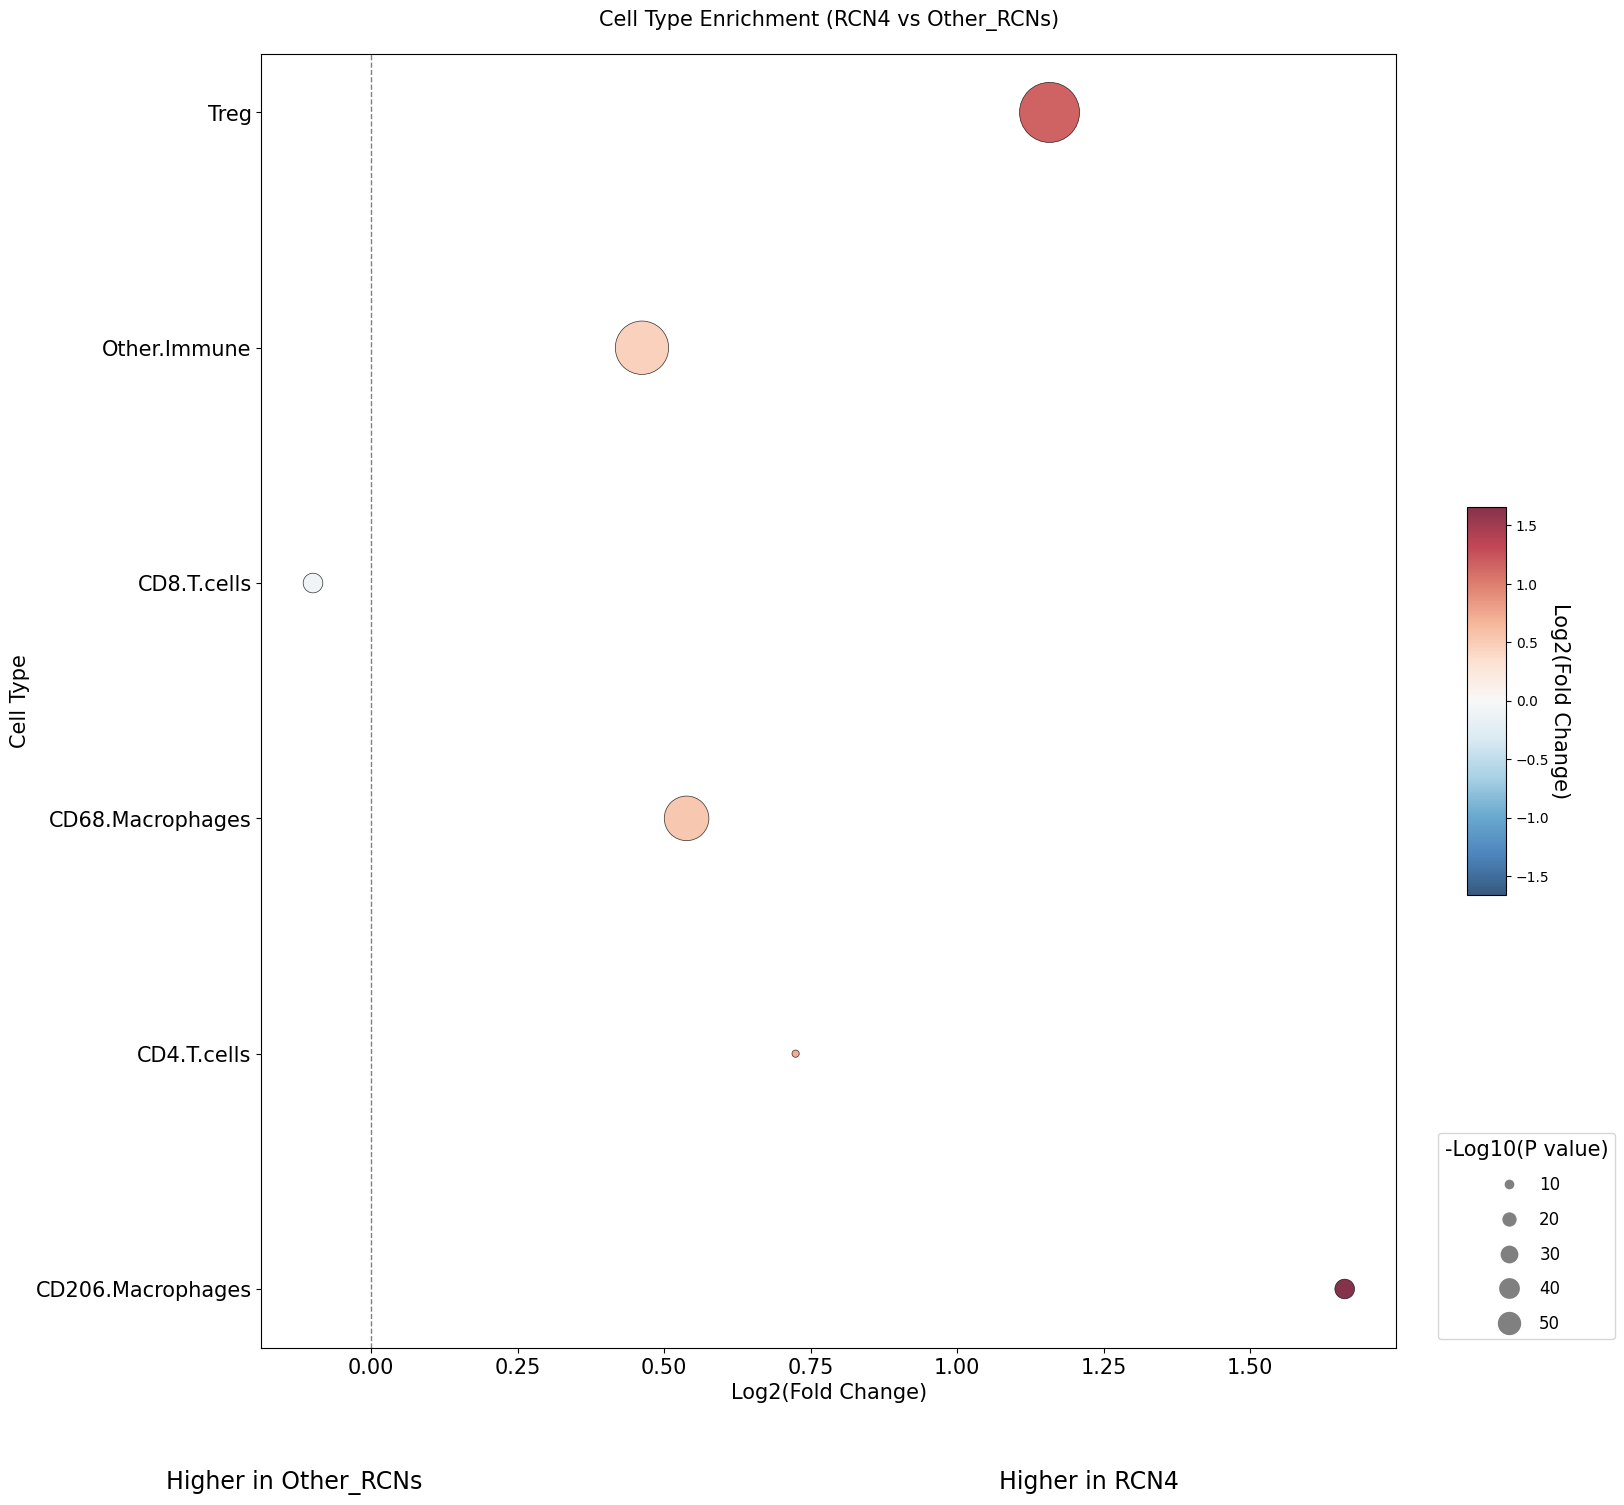

RCNs_2,Other_RCNs,RCN4,Log2(Fold Change),P_value,-Log10(P value)
GCLC_VIM,,,,,
CD206.Macrophages,42.008289,132.857258,1.661131,0.000000e+00,10.000000
CD4.T.cells,66.529570,109.903779,0.724173,4.325538e-02,1.363960
CD68.Macrophages,67.293863,97.715575,0.538114,2.787145e-52,51.554840
CD8.T.cells,57.140279,53.336515,-0.099385,0.000000e+00,10.000000
Other.Immune,56.908299,78.389398,0.462019,1.328363e-74,73.876683
Treg,28.919442,64.510008,1.157483,2.702926e-94,93.568166


In [ ]:
# Compare RCN4 vs Other_RCNs
group_a = 'RCN4'
group_b = 'Other_RCNs'
create_enrichment_bubble_plot(group_a=group_a, 
                              group_b=group_b, 
                              df_proportion=df_proportion_2, 
                              a=20, 
                              output_path=f'/Users/wenqchen/Desktop/Projects/Auria/Plots/Bubble_plot/cell_enrichment_{group_a}_vs_{group_b}_2.pdf')
